In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn import metrics
%matplotlib inline


## EDA

### Structure & Types

In [42]:
df = pd.read_csv('heart.csv')
print(df.shape)
print(df.dtypes)

(918, 12)
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


### Missingness

In [43]:
# check for missing values in each column
df.isna().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Duplication

In [44]:
df.duplicated().sum()

0

In [45]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [46]:
cat_col = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

### Univariate Distribution & Spread

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>, <Axes: >]], dtype=object)

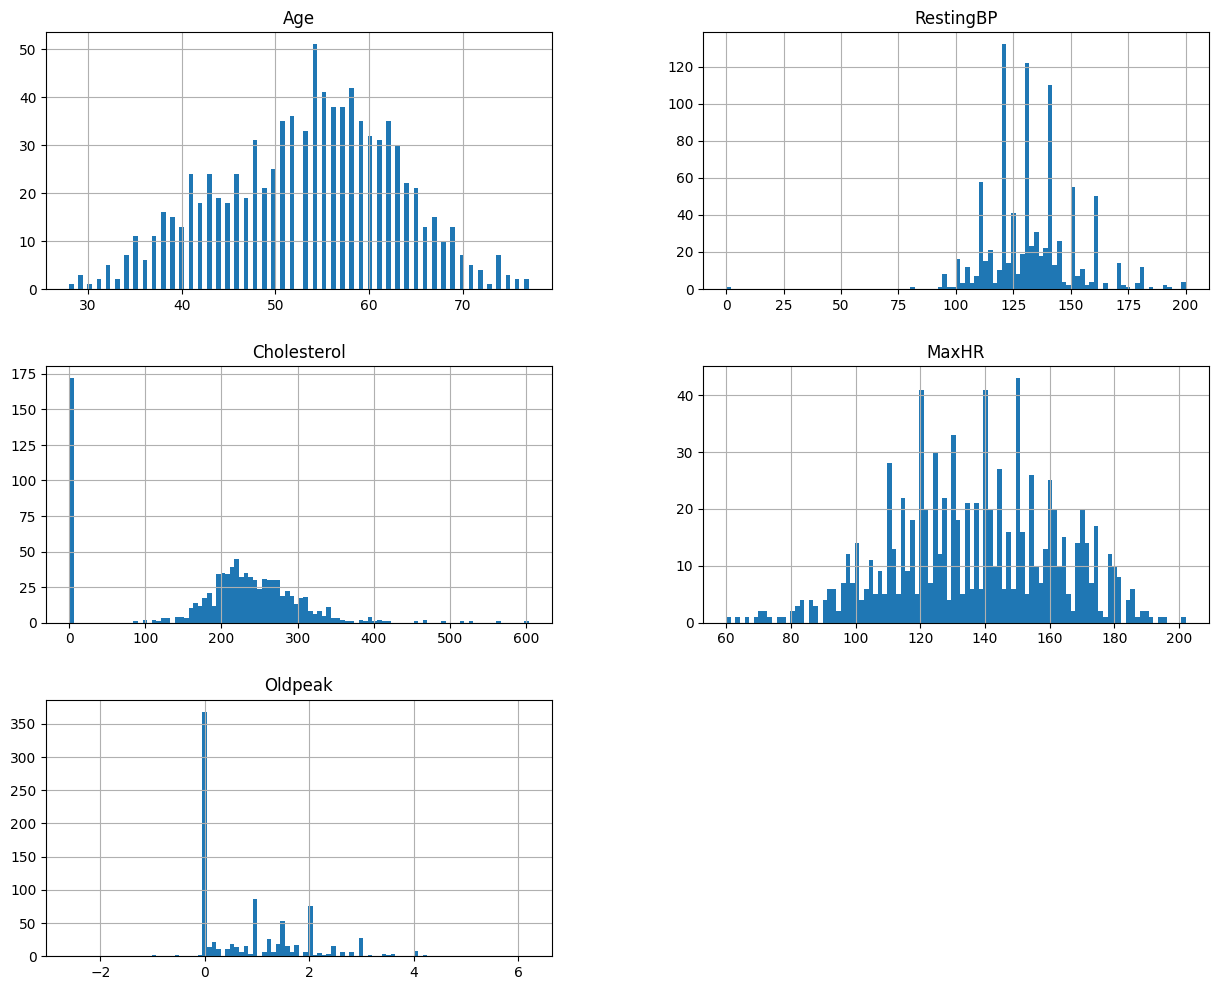

In [47]:
# plot histograms for each numerical column
df[num_col].hist(figsize=(15, 12), bins=100)

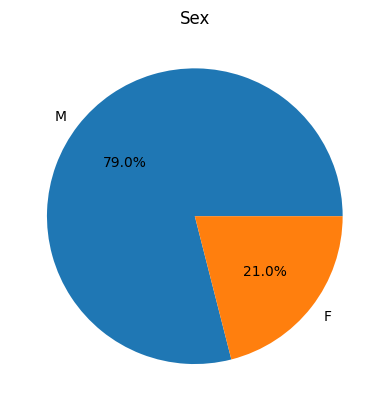

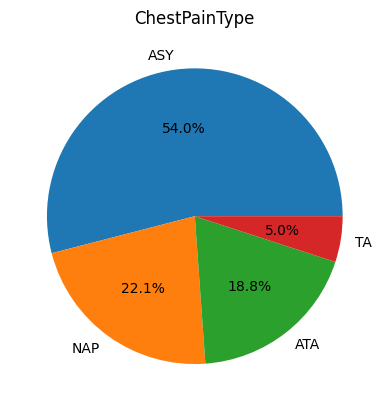

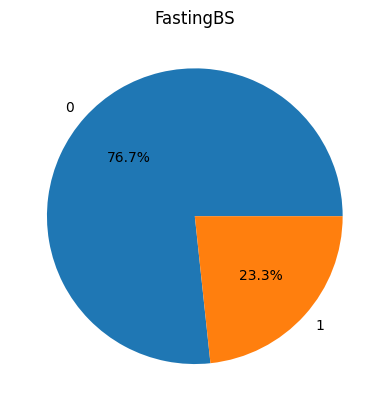

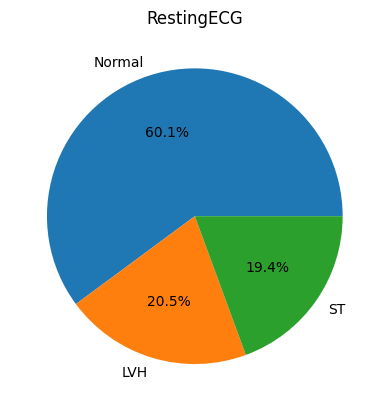

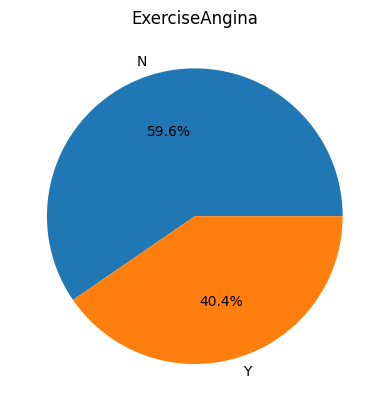

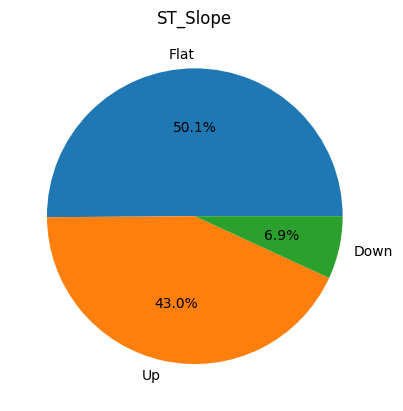

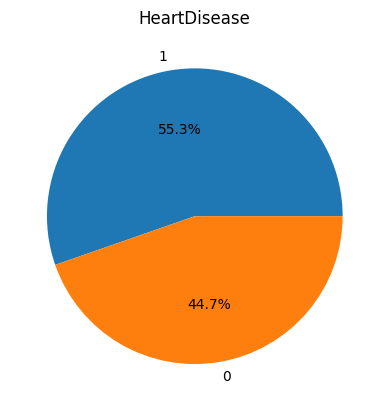

In [48]:
# plot pie charts for each categorical column
for col in cat_col + ['HeartDisease']:
    plt.Figure(figsize=(15, 12))
    # plt.subplot(1, 2, 1)
    plt.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%')
    plt.title(col)
    plt.show()

### Feature Correlation Matrix

<Axes: >

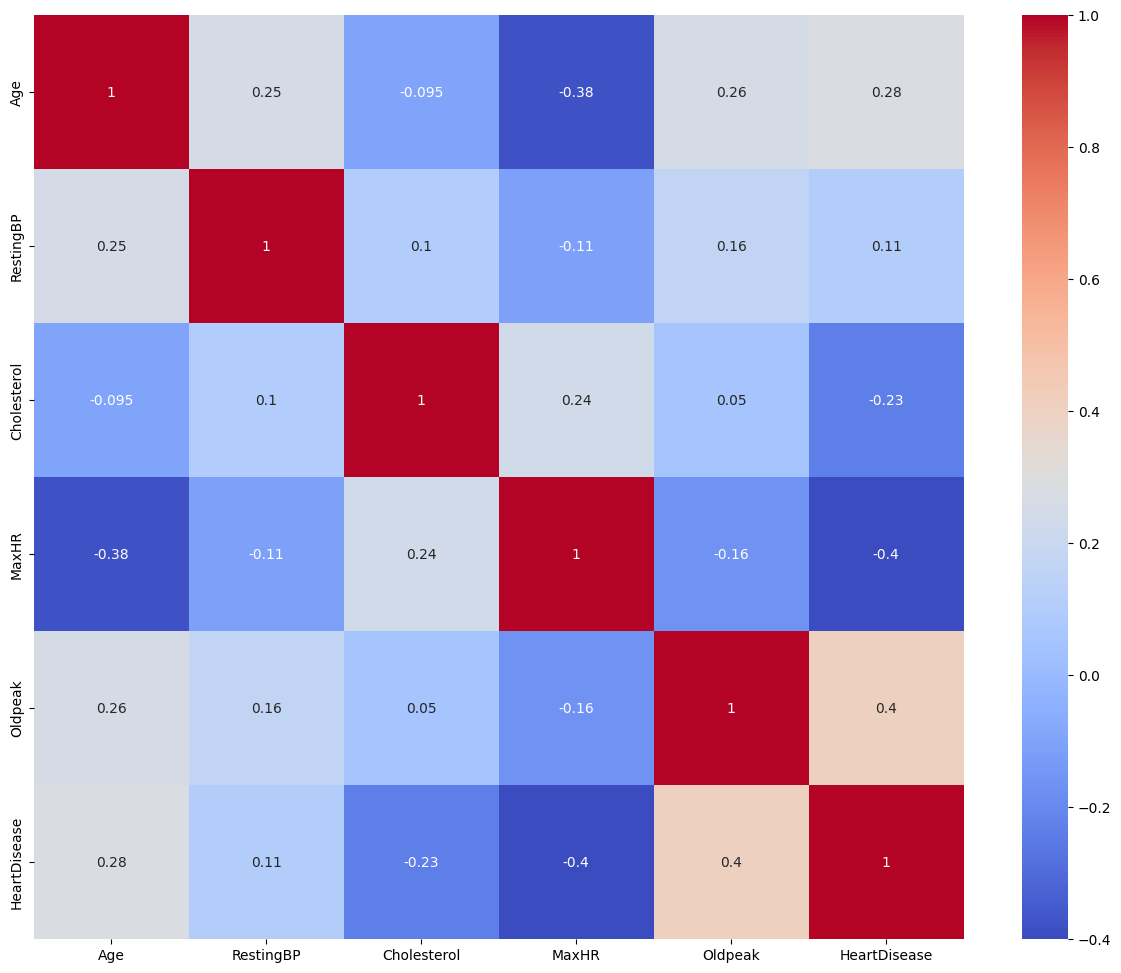

In [49]:
corr = df[num_col + ['HeartDisease']].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')

## Feature Engineering

In [50]:
# handling outliers, using 1.5* IQR    
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# could later try imputing values instead of dropping rows, either with mean feature values or using KNN imputation for observations

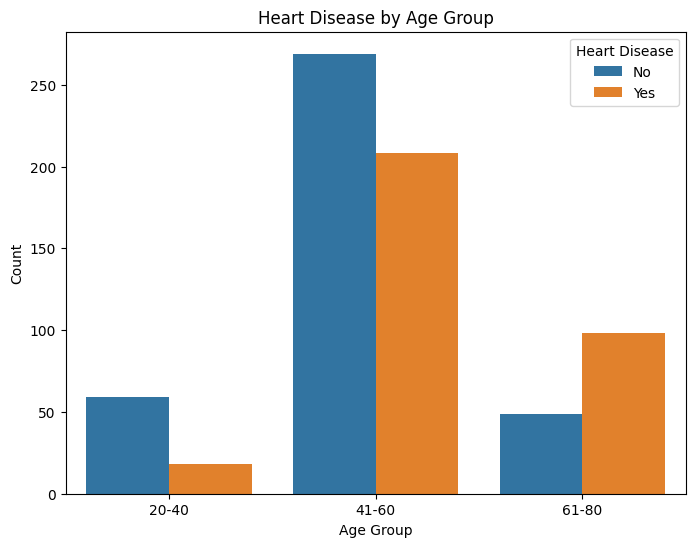

In [51]:
# bin age ranges, create new feature
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[20, 40, 60, 80], 
                        labels=['20-40', '41-60', '61-80'])

cat_col.append('AgeGroup')

plt.figure(figsize=(8, 6))
sns.countplot(data = df, x='AgeGroup', hue='HeartDisease')
plt.title('Heart Disease by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.show()

In [52]:
# one hot encode categorical variables
df = pd.get_dummies(df, columns=cat_col, drop_first=True, dtype='int')
print(df.head())

   Age  RestingBP  Cholesterol  MaxHR  Oldpeak  HeartDisease  Sex_M  \
0   40        140          289    172      0.0             0      1   
1   49        160          180    156      1.0             1      0   
2   37        130          283     98      0.0             0      1   
3   48        138          214    108      1.5             1      0   
4   54        150          195    122      0.0             0      1   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  FastingBS_1  \
0                  1                  0                 0            0   
1                  0                  1                 0            0   
2                  1                  0                 0            0   
3                  0                  0                 0            0   
4                  0                  1                 0            0   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0                  1              0                 0   

In [53]:
# perform feature scaling - standardisation
scalar = StandardScaler()
df[num_col] = scalar.fit_transform(df[num_col])
print(df.head())

        Age  RestingBP  Cholesterol     MaxHR   Oldpeak  HeartDisease  Sex_M  \
0 -1.334331   0.548422     0.984547  1.290461 -0.864955             0      1   
1 -0.390470   1.845686    -1.182352  0.633456  0.178110             1      0   
2 -1.648952  -0.100209     0.865268 -1.748185 -0.864955             0      1   
3 -0.495344   0.418696    -0.506439 -1.337557  0.699642             1      0   
4  0.133897   1.197054    -0.884155 -0.762678 -0.864955             0      1   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  FastingBS_1  \
0                  1                  0                 0            0   
1                  0                  1                 0            0   
2                  1                  0                 0            0   
3                  0                  0                 0            0   
4                  0                  1                 0            0   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0 

## Model Training

In [54]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

### Models

In [55]:
# use l1_ratio=0 for L2 regularisation
log_model = LogisticRegression(l1_ratio=0, solver='liblinear', max_iter=1000, random_state=42)

knn_model = KNeighborsClassifier()

rand_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

XGBoost_model = XGBClassifier(eval_metric='logloss',max_depth=4,learning_rate=0.1, n_estimators=100, random_state=42)

models = [('logistic regression', log_model), 
          ('knn', knn_model), 
          ('random forest', rand_forest_model), 
          ('gradient boost', XGBoost_model)]

## Hyperparameter Tuning with Cross Validation

In [56]:
# using GridSearchCV to combine hyperparameter tuning with cross validation to find optimal hyperparameters for each model

# set up parameter grids for each model
param_grid_log = {
    'l1_ratio': [0, 1],
    'max_iter': [500, 750, 1000]
}
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9]
}
param_grid_random_forest = {
    'n_estimators': [50, 100, 200]
}
param_grid_xgboost = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [50, 100, 200]
}

# set up grid search for each model
grid_log = GridSearchCV(
    estimator = log_model,
    param_grid = param_grid_log,
    scoring = 'roc_auc',
    cv = 5
)
grid_knn = GridSearchCV(
    estimator = knn_model,
    param_grid = param_grid_knn,
    scoring = 'roc_auc',
    cv = 5
)
grid_rand_forest = GridSearchCV(
    estimator = rand_forest_model,
    param_grid = param_grid_random_forest,
    scoring = 'roc_auc',
    cv = 5
)
grid_xgboost = GridSearchCV(
    estimator = XGBoost_model,
    param_grid = param_grid_xgboost,
    scoring = 'roc_auc',
    cv = 5
)

# fit each grid search to the training data
grid_log.fit(X_train, y_train)
grid_knn.fit(X_train, y_train)
grid_rand_forest.fit(X_train, y_train)
grid_xgboost.fit(X_train, y_train)

# print best hyperparameters for each model
print(f'Logistic Regression AUC: {round(grid_log.best_score_, 4)}')
log_model = grid_log.best_estimator_
print(f'K-Nearest Neighbors AUC: {round(grid_knn.best_score_, 4)}')
knn_model = grid_knn.best_estimator_
print(f'Random Forest AUC: {round(grid_rand_forest.best_score_, 4)}')
rand_forest_model = grid_rand_forest.best_estimator_
print(f'XGBoost AUC: {round(grid_xgboost.best_score_, 4)}')
XGBoost_model = grid_xgboost.best_estimator_

Logistic Regression AUC: 0.9586
K-Nearest Neighbors AUC: 0.9163
Random Forest AUC: 0.9515
XGBoost AUC: 0.9499


In [57]:
#kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#for name, model in models:
    #cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['f1', 'roc_auc', 'precision', 'recall', 'accuracy'])
    #print(f'########## {name} ##########')
    #print(f'Accuracy: {round(cv_results["test_accuracy"].mean(), 4)}')
    #print(f'Auc: {round(cv_results["test_roc_auc"].mean(), 4)}')
    #print(f'Recall: {round(cv_results["test_recall"].mean(), 4)}')
    #print(f'Precision: {round(cv_results["test_precision"].mean(), 4)}')
    #print(f'F1: {round(cv_results["test_f1"].mean(), 4)}')

## Final Model Evaluation

In [58]:
y_pred = log_model.predict(X_test)
print("auc-roc:", metrics.roc_auc_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))

auc-roc: 0.8417419354838709
f1: 0.8265107212475633


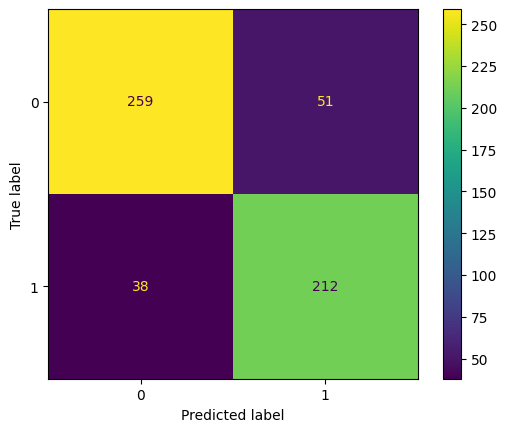

In [62]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()